In [58]:
import pandas as pd

In [59]:
df = pd.read_csv("../../data/final_train_data/player_data.csv", index_col=False)

In [60]:
df_match = pd. read_csv("../../data/final_train_data/match.csv")

# Formula

In [61]:
import pandas as pd
import numpy as np

# -----------------------------
# Hyperparameters (easy to tune)
# -----------------------------
ALPHA = 1.3  # weight sharpness

N_SELECT = {
    "FW": 4,
    "MF": 4,
    "DF": 4,
    "GK": 2
}

# -----------------------------
# Selection score
# -----------------------------
df["selection_score"] = (
    0.6 * df["overall_rating"] +
    0.4 * df["base_stats"]
)

# -----------------------------
# Helper: weighted mean
# -----------------------------
def weighted_mean(values, weights):
    return np.sum(values * weights)

# -----------------------------
# Stat formulas (vectorized)
# -----------------------------
def attacking_score(d):
    return (
        0.25 * d["finishing"] +
        0.20 * d["shot_power"] +
        0.20 * d["attack_position"] +
        0.20 * d["ball_control"] +
        0.15 * d["short_passing"]
    )

def defensive_score(d):
    return (
        0.35 * d["defensive_awareness"] +
        0.30 * d["standing_tackle"] +
        0.20 * d["interceptions"] +
        0.15 * d["strength"]
    )

def gk_score(d):
    return (
        0.30 * d["gk_reflexes"] +
        0.25 * d["gk_diving"] +
        0.20 * d["gk_positioning"] +
        0.15 * d["gk_handling"] +
        0.10 * d["reactions"]
    )

def physical_score(d):
    return (
        0.30 * d["sprint_speed"] +
        0.25 * d["acceleration"] +
        0.25 * d["stamina"] +
        0.20 * d["balance"]
    )

# -----------------------------
# Main aggregation
# -----------------------------
team_rows = []

group_keys = ["team", "roster_date"]

for (team, roster_date), g in df.groupby(group_keys):

    selected_players = []

    # ---- player selection per position ----
    for pos, n in N_SELECT.items():
        pos_players = (
            g[g["general_position"] == pos]
            .sort_values("selection_score", ascending=False)
            .head(n)
        )
        if len(pos_players) < n:
            break  # skip incomplete rosters
        selected_players.append(pos_players)

    if len(selected_players) != 4:
        continue

    roster = pd.concat(selected_players)

    # ---- compute position-normalized weights ----
    roster["weight"] = 0.0

    for pos in N_SELECT.keys():
        mask = roster["general_position"] == pos
        scores = roster.loc[mask, "selection_score"] ** ALPHA
        roster.loc[mask, "weight"] = scores / scores.sum()

    # ---- compute individual component scores ----
    roster["A"] = attacking_score(roster)
    roster["D"] = defensive_score(roster)
    roster["G"] = gk_score(roster)
    roster["P"] = physical_score(roster)

    # ---- position-level aggregation ----
    A_FW = weighted_mean(
        roster.loc[roster.general_position == "FW", "A"],
        roster.loc[roster.general_position == "FW", "weight"]
    )
    A_MF = weighted_mean(
        roster.loc[roster.general_position == "MF", "A"],
        roster.loc[roster.general_position == "MF", "weight"]
    )

    D_DF = weighted_mean(
        roster.loc[roster.general_position == "DF", "D"],
        roster.loc[roster.general_position == "DF", "weight"]
    )
    D_MF = weighted_mean(
        roster.loc[roster.general_position == "MF", "D"],
        roster.loc[roster.general_position == "MF", "weight"]
    )

    G_team = weighted_mean(
        roster.loc[roster.general_position == "GK", "G"],
        roster.loc[roster.general_position == "GK", "weight"]
    )

    P_team = weighted_mean(
        roster.loc[roster.general_position != "GK", "P"],
        roster.loc[roster.general_position != "GK", "weight"]
    )

    # ---- team-level scores ----
    A_team = 0.6 * A_FW + 0.4 * A_MF
    D_team = 0.7 * D_DF + 0.3 * D_MF

    T_overall = (
        0.35 * A_team +
        0.30 * D_team +
        0.20 * G_team +
        0.15 * P_team
    )

    team_rows.append({
        "team": team,
        "roster_date": roster_date,
        "attack": A_team,
        "defense": D_team,
        "goalkeeping": G_team,
        "physical": P_team,
        "team_overall": T_overall
    })

# -----------------------------
# Final team-level DataFrame
# -----------------------------
team_stats_df = pd.DataFrame(team_rows)

# Merge

In [62]:
import warnings
warnings.filterwarnings("ignore")


# Import merge module
import sys
sys.path.append('../merge')
from merge import merge_match_with_team_stats

# Merge match data with team statistics
df_match_enriched = merge_match_with_team_stats(df_match, team_stats_df, verbose=True)

# Display sample
print(f"\nSample of enriched data:")
df_match_enriched[['home_team', 'away_team', 'month', 'year', 'home_team_overall', 'away_team_overall', 'home_team_win']].head(10)

Merging home team statistics...
Merging away team statistics...

Original matches: 2820
Matches with team stats: 1569
Matches dropped: 1251

New columns added: ['home_team', 'away_team', 'home_score', 'away_score', 'home_team_win', 'home_attack', 'home_defense', 'home_goalkeeping', 'home_physical', 'home_team_overall', 'away_attack', 'away_defense', 'away_goalkeeping', 'away_physical', 'away_team_overall']

Sample of enriched data:


,home_team,away_team,month,year,home_team_overall,away_team_overall,home_team_win
1,Aston Villa,Brighton & Hove Albion,May,2023.0,96.395743,92.726089,1.0
2,Brentford,Manchester,May,2023.0,95.371138,103.163306,1.0
3,Chelsea,Newcastle United,May,2023.0,102.932683,98.576274,0.5
4,Crystal Palace,Nottingham Forest,May,2023.0,96.245376,95.314917,0.5
6,Leeds United,Tottenham Hotspur,May,2023.0,95.512227,101.025591,0.0
7,Leicester City,West Ham United,May,2023.0,97.000569,97.884260,1.0
8,Manchester United,Fulham,May,2023.0,100.978993,93.931167,1.0
9,Southampton,Liverpool,May,2023.0,96.158040,103.700187,0.5
10,Manchester United,Chelsea,May,2023.0,100.978993,102.932683,1.0
11,Brighton & Hove Albion,Manchester,May,2023.0,92.726089,103.163306,0.5


# Training

In [63]:
# Import training module
import sys
sys.path.append('../train')
from training import train_all_models

# Define feature columns
feature_cols = [
    'home_attack', 'home_defense', 'home_goalkeeping', 'home_physical', 'home_team_overall',
    'away_attack', 'away_defense', 'away_goalkeeping', 'away_physical', 'away_team_overall'
]

# Train all models (binary classification: away_win vs home_win)
training_results = train_all_models(df_match_enriched, feature_cols, test_size=0.2, random_state=42)

# Extract results for plotting
comparison_df = training_results['comparison']

Binary Classification - Class distribution:
  Away wins: 440
  Home wins: 704
  Total matches (excluding draws): 1144
  Draws excluded: 425

Training set: 915 samples
Test set: 229 samples

LOGISTIC REGRESSION
Accuracy: 0.6550

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.58      0.38      0.46        88
    Home Win       0.68      0.83      0.75       141

    accuracy                           0.66       229
   macro avg       0.63      0.60      0.60       229
weighted avg       0.64      0.66      0.64       229


Confusion Matrix:
[[ 33  55]
 [ 24 117]]

RANDOM FOREST
Accuracy: 0.6157

Classification Report:
              precision    recall  f1-score   support

    away_win       0.50      0.47      0.48        88
    home_win       0.68      0.71      0.69       141

    accuracy                           0.62       229
   macro avg       0.59      0.59      0.59       229
weighted avg       0.61      0.62      0.61       22

## Visualize Results

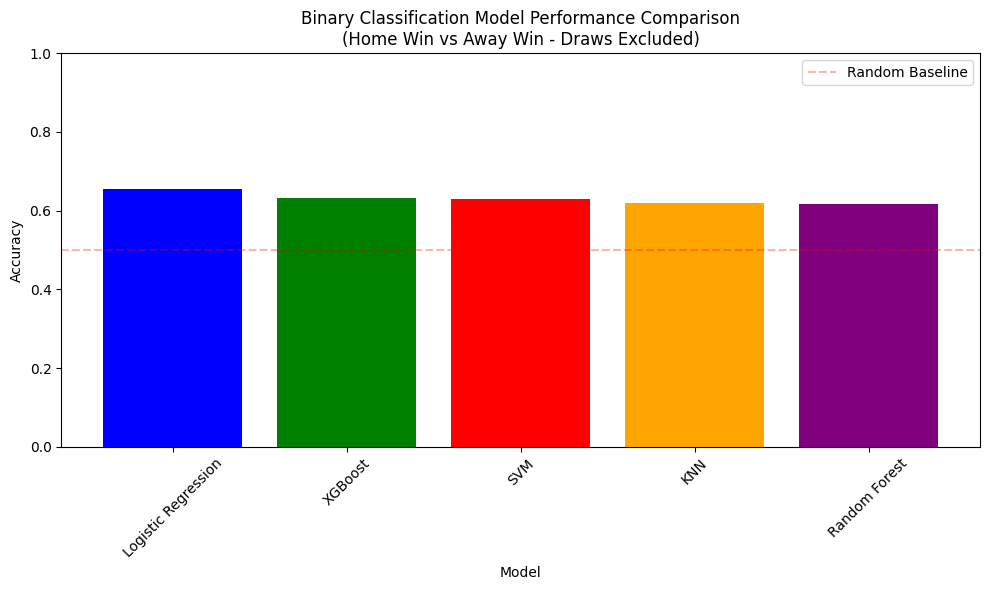

In [64]:
import matplotlib.pyplot as plt

# Visualize comparison
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'], 
        color=['blue', 'green', 'red', 'orange', 'purple'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Binary Classification Model Performance Comparison\n(Home Win vs Away Win - Draws Excluded)')
plt.ylim(0.0, 1.0)
plt.xticks(rotation=45)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3, label='Random Baseline')
plt.legend()
plt.tight_layout()
plt.show()